DATASET OVERVIEW

Shape of Dataset:
(16598, 11)

Columns:
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

Missing Values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Duplicate Records:
0

Top 10 Platforms by Global Sales:
Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
PS       730.66
GBA      318.50
PSP      296.28
PS4      278.10
PC       258.82
Name: Global_Sales, dtype: float64


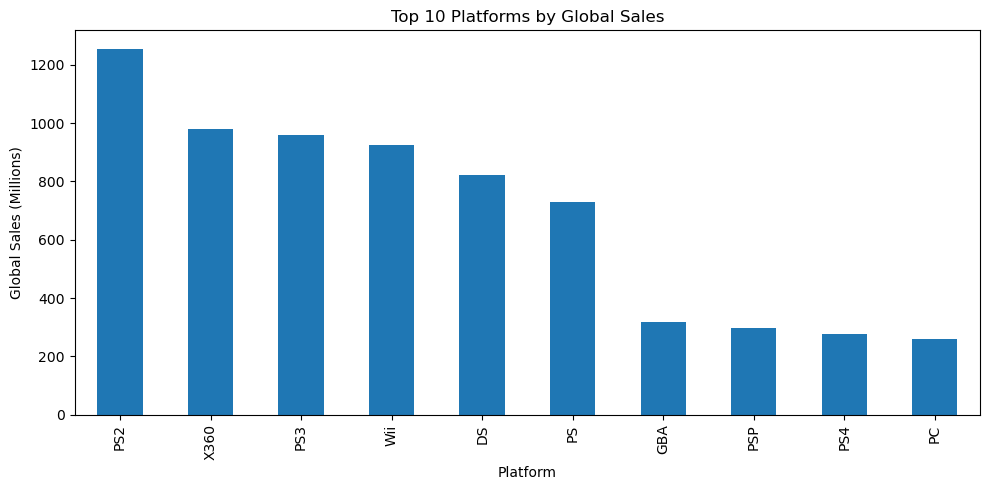


Top Genres by Global Sales:
Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Misc             809.96
Racing           732.04
Fighting         448.91
Simulation       392.20
Puzzle           244.95
Adventure        239.04
Strategy         175.12
Name: Global_Sales, dtype: float64


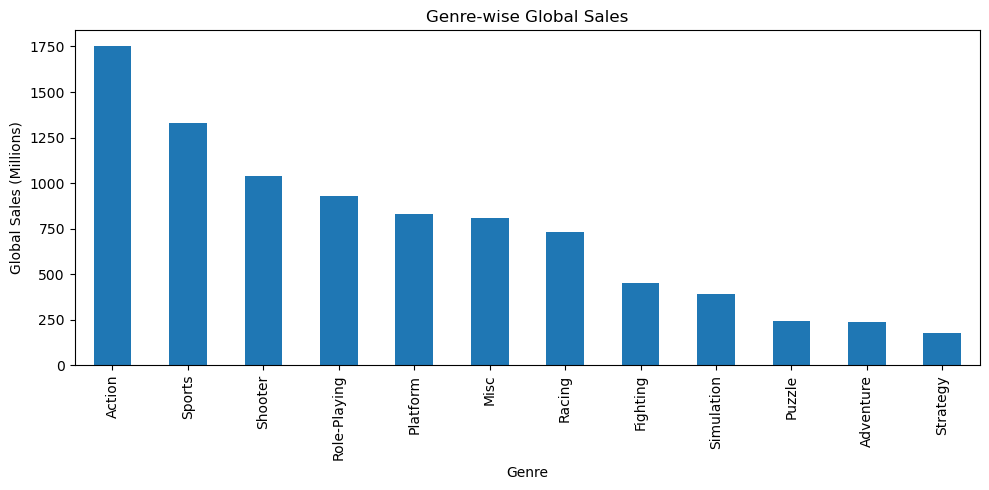


Top 10 Publishers:
Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64


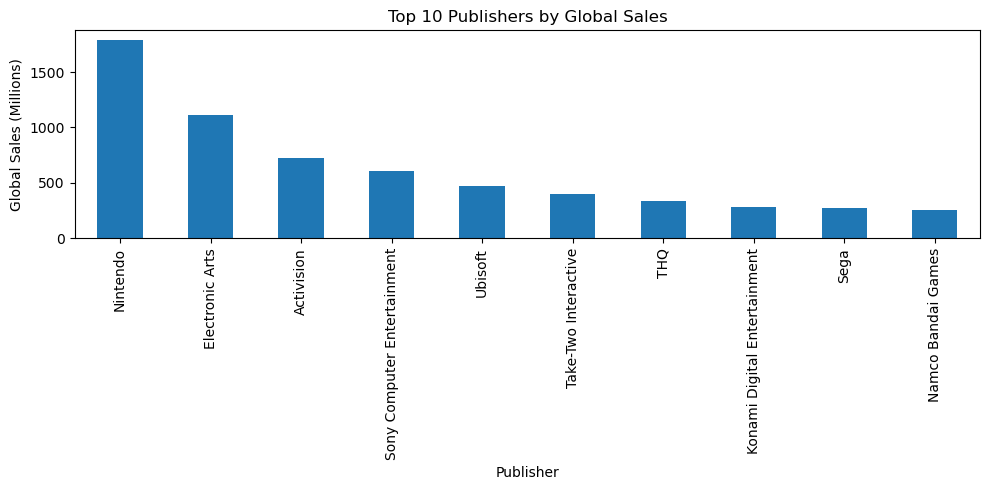


Top 10 Selling Games:
                        Name Platform  Global_Sales
0                 Wii Sports      Wii         82.74
1          Super Mario Bros.      NES         40.24
2             Mario Kart Wii      Wii         35.82
3          Wii Sports Resort      Wii         33.00
4   Pokemon Red/Pokemon Blue       GB         31.37
5                     Tetris       GB         30.26
6      New Super Mario Bros.       DS         30.01
7                   Wii Play      Wii         29.02
8  New Super Mario Bros. Wii      Wii         28.62
9                  Duck Hunt      NES         28.31

Best Sales Year: 2008.0
Sales: 678.9 Million Units


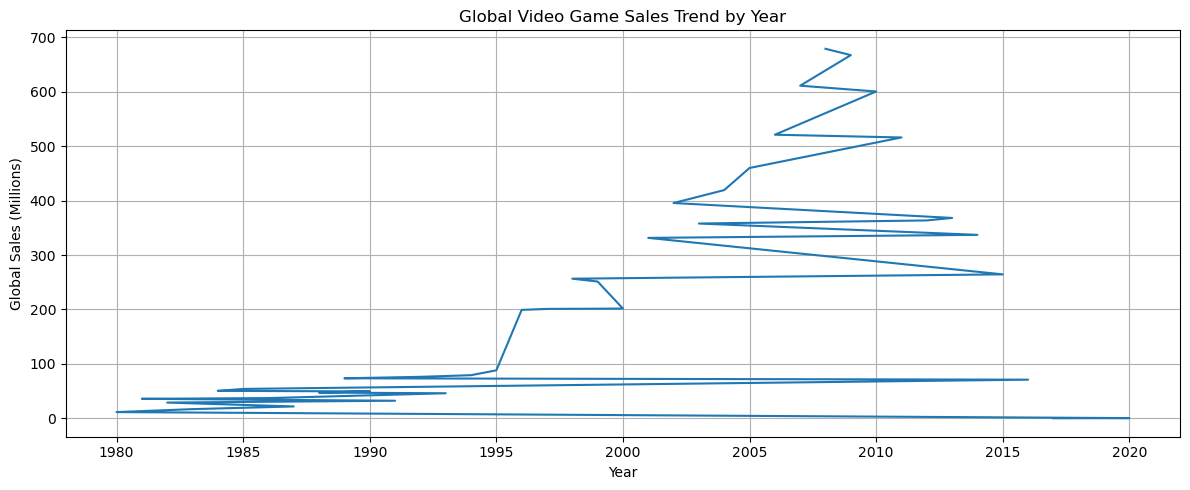


Regional Sales:
NA_Sales       4392.95
EU_Sales       2434.13
JP_Sales       1291.02
Other_Sales     797.75
dtype: float64


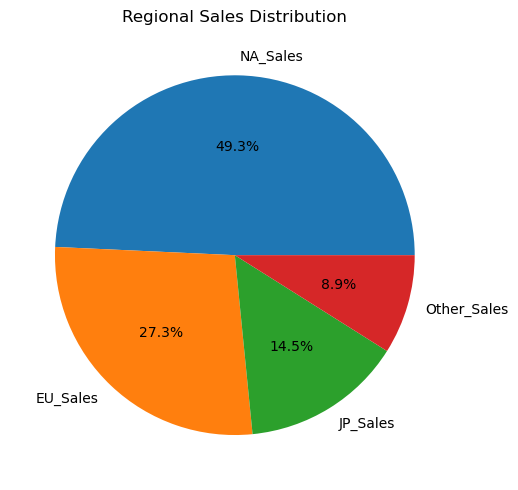


KEY INSIGHTS
1. Best Platform: PS2 (1255.64M sales)
2. Best Genre: Action (1751.18M sales)
3. Best Publisher: Nintendo (1786.56M sales)
4. Best Year: 2008.0 (678.90M sales)
5. Best Selling Game: Wii Sports (82.74M sales)

Task Completed Successfully!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("vgsales.csv")

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()


platform_sales = (
    df.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Platforms by Global Sales:")
print(platform_sales)

plt.figure(figsize=(10,5))
platform_sales.plot(kind="bar")
plt.title("Top 10 Platforms by Global Sales")
plt.ylabel("Global Sales (Millions)")
plt.tight_layout()
plt.show()

genre_sales = (
    df.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop Genres by Global Sales:")
print(genre_sales)

plt.figure(figsize=(10,5))
genre_sales.plot(kind="bar")
plt.title("Genre-wise Global Sales")
plt.ylabel("Global Sales (Millions)")
plt.tight_layout()
plt.show()

publisher_sales = (
    df.groupby("Publisher")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Publishers:")
print(publisher_sales)

plt.figure(figsize=(10,5))
publisher_sales.plot(kind="bar")
plt.title("Top 10 Publishers by Global Sales")
plt.ylabel("Global Sales (Millions)")
plt.tight_layout()
plt.show()

top_games = (
    df[["Name", "Platform", "Global_Sales"]]
    .sort_values("Global_Sales", ascending=False)
    .head(10)
)

print("\nTop 10 Selling Games:")
print(top_games)

year_sales = (
    df.groupby("Year")["Global_Sales"]
    .sum()
    .sort_values()
)

best_year = year_sales.idxmax()
best_sales = year_sales.max()

print("\nBest Sales Year:", best_year)
print("Sales:", round(best_sales, 2), "Million Units")

plt.figure(figsize=(12,5))
year_sales.plot()
plt.title("Global Video Game Sales Trend by Year")
plt.ylabel("Global Sales (Millions)")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()

regions = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]

region_totals = df[regions].sum()

print("\nRegional Sales:")
print(region_totals)

plt.figure(figsize=(8,5))
region_totals.plot(kind="pie", autopct="%1.1f%%")
plt.title("Regional Sales Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

print(f"1. Best Platform: {platform_sales.idxmax()} ({platform_sales.max():.2f}M sales)")
print(f"2. Best Genre: {genre_sales.idxmax()} ({genre_sales.max():.2f}M sales)")
print(f"3. Best Publisher: {publisher_sales.idxmax()} ({publisher_sales.max():.2f}M sales)")
print(f"4. Best Year: {best_year} ({best_sales:.2f}M sales)")
print(f"5. Best Selling Game: {top_games.iloc[0]['Name']} ({top_games.iloc[0]['Global_Sales']}M sales)")

print("\nTask Completed Successfully!")